In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_m = pd.read_csv('../data/SPMP_MAG-info.tsv', sep='\t', usecols=['mag_id','sample_id','genus','phylum','perc_abun'])

Host associations by linkage method

In [2]:
df_pr = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='prophage', usecols=['votu_id','sample_id','genus','phylum']).drop_duplicates()
df_pr['linkage_method'] = 'pr'
df_sp = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='spacer matching', usecols=['votu_id','sample_id','genus','phylum']).drop_duplicates()
df_sp['linkage_method'] = 'sp'
df_hc = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='Hi-C', usecols=['votu_id','sample_id','genus','phylum']).drop_duplicates()
df_hc['linkage_method'] = 'hc'

df_vh_all = pd.concat([df_pr, df_sp, df_hc], ignore_index=True)

Compile number of vOTUs as linkage methods are included

In [3]:
df_vh = df_vh_all.groupby(['votu_id','genus','phylum'], as_index=False)['linkage_method'].agg(list)

df_vh['pr'] = df_vh['linkage_method'].apply(lambda x: int('pr' in x))
df_vh['sp'] = df_vh['linkage_method'].apply(lambda x: int('sp' in x))
df_vh['hc'] = df_vh['linkage_method'].apply(lambda x: int('hc' in x))

df_vh['sp_not_pr'] = df_vh.apply(lambda row: int(row['sp'] == 1 and row['pr'] == 0), axis=1)
df_vh['hc_not_prsp'] = df_vh.apply(lambda row: int(row['hc'] == 1 and row['pr'] == 0 and row['sp'] == 0), axis=1)

df_h = df_vh.groupby(['genus','phylum'], as_index=False).agg({'pr': 'sum', 'sp_not_pr': 'sum', 'hc_not_prsp': 'sum', 'votu_id': 'count'}).rename(columns={'votu_id':'num_votus'})

No. of MAGs in genus

In [4]:
df_gn = df_m.groupby('genus', as_index=False).agg(num_mags = ('mag_id', 'count'))
df_h = df_h.merge(df_gn, on='genus', how='left')

Genus prevalence

In [5]:
df_gp = df_m.groupby('genus', as_index=False).agg(prevalence_g = ('sample_id', 'nunique'))
df_gp.prevalence_g = df_gp.prevalence_g/109*100
df_h = df_h.merge(df_gp, on='genus', how='left')

Median genus abundance

In [6]:
df_ga = df_m.groupby(['genus','sample_id'], as_index=False).perc_abun.sum().groupby('genus', as_index=False).agg(median_perc_abun_g = ('perc_abun', 'median'))
df_h = df_h.merge(df_ga, on='genus', how='left')

Median abundance of vOTUs infecting a genus

In [7]:
df_va = pd.read_excel('../data/Supplementary_Data_7_vOTU_and_MAG_abundance_estimation.xlsx', sheet_name='votu-bulk', usecols=['votu_id','sample_id','perc_abun'])

df_vh2 = df_vh_all[['votu_id','sample_id','genus']].drop_duplicates().merge(df_va, on=['votu_id','sample_id'], how='left')
df_vh2.perc_abun = df_vh2.perc_abun.fillna(0)

df_gva = df_vh2.groupby(['sample_id','genus'], as_index=False).perc_abun.sum().groupby('genus', as_index=False).agg(median_perc_abun_v = ('perc_abun', 'median'))
df_h = df_h.merge(df_gva, on='genus', how='left')

### Fig. 2B: no. of vOTUs infecting host genera as host linkage methods are added (prophage &rarr; spacer matching &rarr; Hi-C)

In [8]:
n=100

df_h2 = df_h.loc[df_h.num_votus >= n]

df_h2 = df_h2.sort_values(['num_votus','genus'], ascending=[False,True])

len(df_h2)

55

In [9]:
hcolor_dict = {'Firmicutes_A': 'r', 'Firmicutes': 'r', 'Firmicutes_C': 'r', 'Firmicutes_B': 'r',
               'Bacteroidota': 'g',
               'Actinobacteriota': 'b',
               'Desulfobacterota': 'purple',
               'Proteobacteria': 'orange',
               'Synergistota': 'k', 'Methanobacteriota': 'k', 'Spirochaetota': 'k', 'Elusimicrobiota': 'k', 'Verrucomicrobiota': 'k', 'Fusobacteriota': 'k'}

h_color = df_h2.phylum.apply(lambda x: hcolor_dict[x]).tolist()

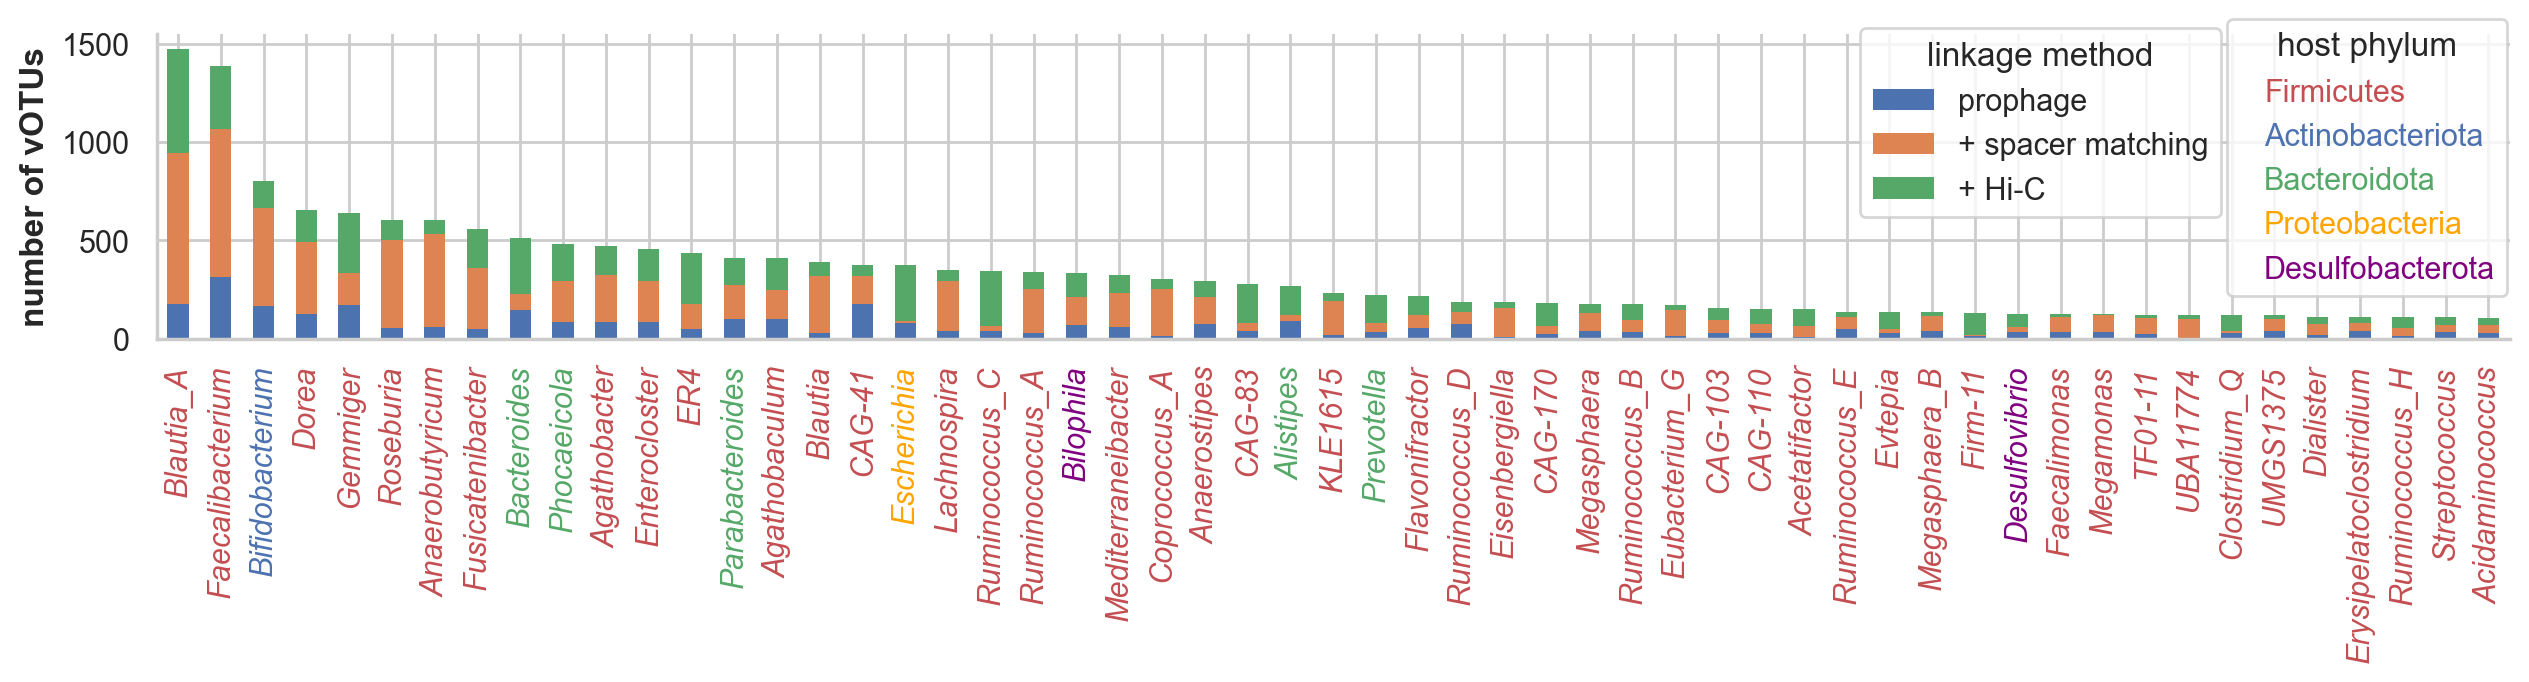

In [10]:
sns.set(style='whitegrid')

fig, ax = plt.subplots(figsize=(13, 3.5), dpi=200)

df_h2[['genus','pr','sp_not_pr','hc_not_prsp']].set_index('genus').plot(kind='bar', stacked=True, ax=ax, linewidth=0) # pr -> sp -> hc

plt.title('')
plt.ylabel('number of vOTUs', fontweight='bold')
plt.xlabel('')
plt.yticks(range(0,2500,500))

ax.set_xticklabels([f"{g.get_text()}" for g in ax.get_xticklabels()], fontstyle='italic')

for ticklabel, tickcolor in zip(plt.gca().get_xticklabels(), h_color):
    ticklabel.set_color(tickcolor)

legend_handles, _ = ax.get_legend_handles_labels()
legend1 = ax.legend(legend_handles, ['prophage','+ spacer matching','+ Hi-C'], title='linkage method', loc=(0.724,0.4)) # pr -> sp -> hc

h_phy = ['Firmicutes','Actinobacteriota','Bacteroidota','Proteobacteria','Desulfobacterota']
h_col = ['r','b','g','orange','purple']
for p,c in zip(h_phy,h_col):
    plt.plot([], [], ' ', color=c, label=p)
legend_handles, _ = ax.get_legend_handles_labels()
leg = ax.legend(legend_handles[:5], h_phy, title='host phylum', loc=(0.88,0.14), labelcolor='linecolor', handlelength=0)

plt.gca().add_artist(legend1) # add back the first legend

sns.despine()
plt.tight_layout()

### Supplementary Fig. 16A: quantities correlating with no. of vOTUs infecting host genera

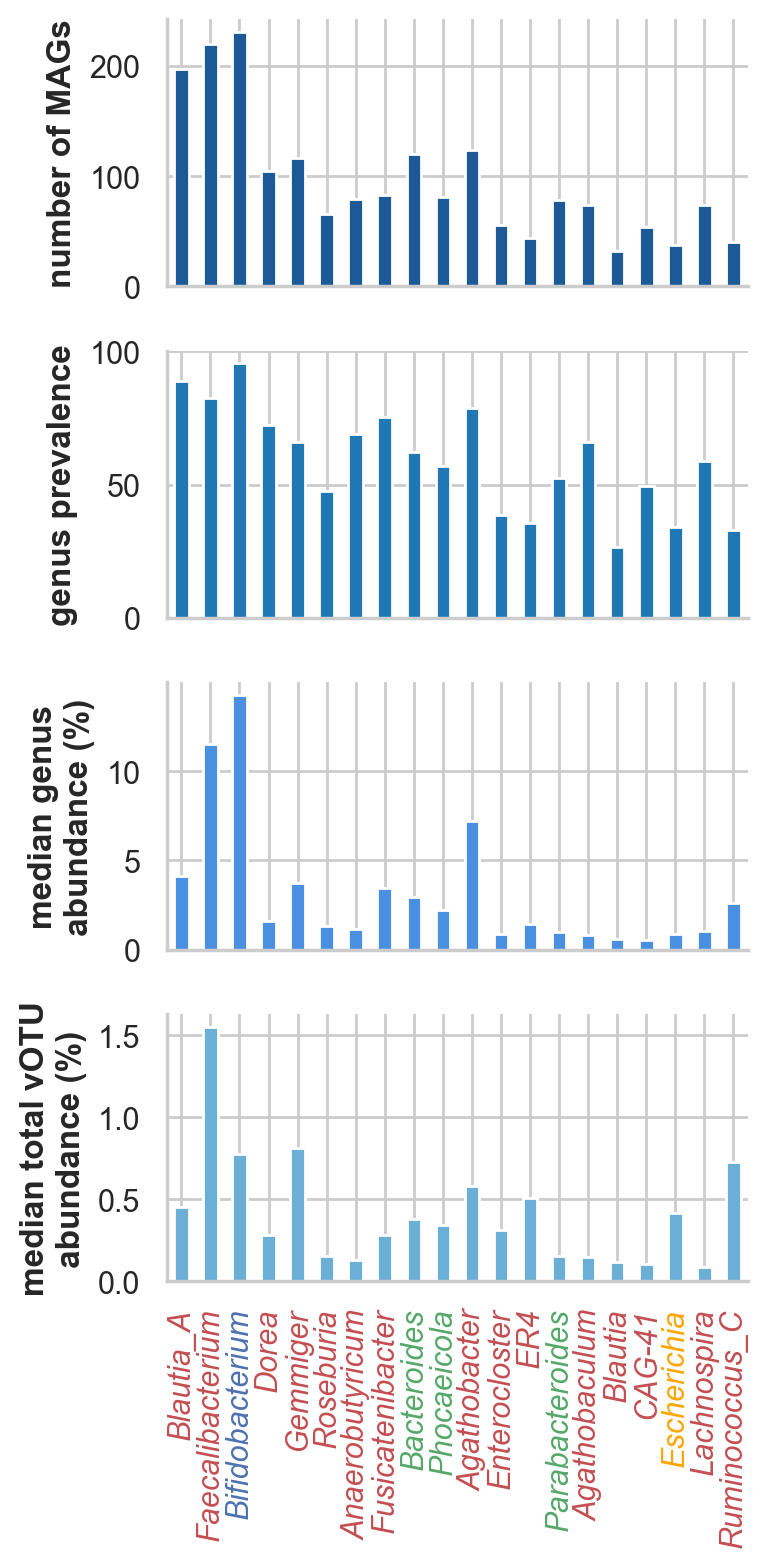

In [11]:
sns.set(style='whitegrid')

fig, ax = plt.subplots(4,1, figsize=(4, 8), sharex=True, dpi=200)

colors = ["#1c5a97", '#1f77b4','#4a90e2','#6baed6']

df_h3 = df_h2[:20]

df_h3[['genus','num_mags']].set_index('genus').plot(kind='bar', ax=ax[0], color=colors[0])
df_h3[['genus','prevalence_g']].set_index('genus').plot(kind='bar', ax=ax[1], color=colors[1])
df_h3[['genus','median_perc_abun_g']].set_index('genus').plot(kind='bar', ax=ax[2], color=colors[2])
df_h3[['genus','median_perc_abun_v']].set_index('genus').plot(kind='bar', ax=ax[3], color=colors[3])

plt.title('')
ax[0].set_ylabel('number of MAGs', fontweight='bold')
ax[1].set_ylabel('genus prevalence', fontweight='bold')
ax[2].set_ylabel('median genus\nabundance (%)', fontweight='bold')
ax[3].set_ylabel('median total vOTU\nabundance (%)', fontweight='bold')
plt.xlabel('')

for ticklabel, tickcolor in zip(plt.gca().get_xticklabels(), h_color):
    ticklabel.set_color(tickcolor)

ax[0].legend_.remove()
ax[1].legend_.remove()
ax[2].legend_.remove()
ax[3].legend_.remove()

ax[3].set_xticklabels([f"{g.get_text()}" for g in ax[3].get_xticklabels()], fontstyle='italic')

sns.despine()
plt.tight_layout()

### Supplementary Fig. 16B: correlation plots of quantities vs. no. of vOTUs infecting host genera

In [12]:
n = 10

df_h4 = df_h.loc[df_h.num_votus >= n]

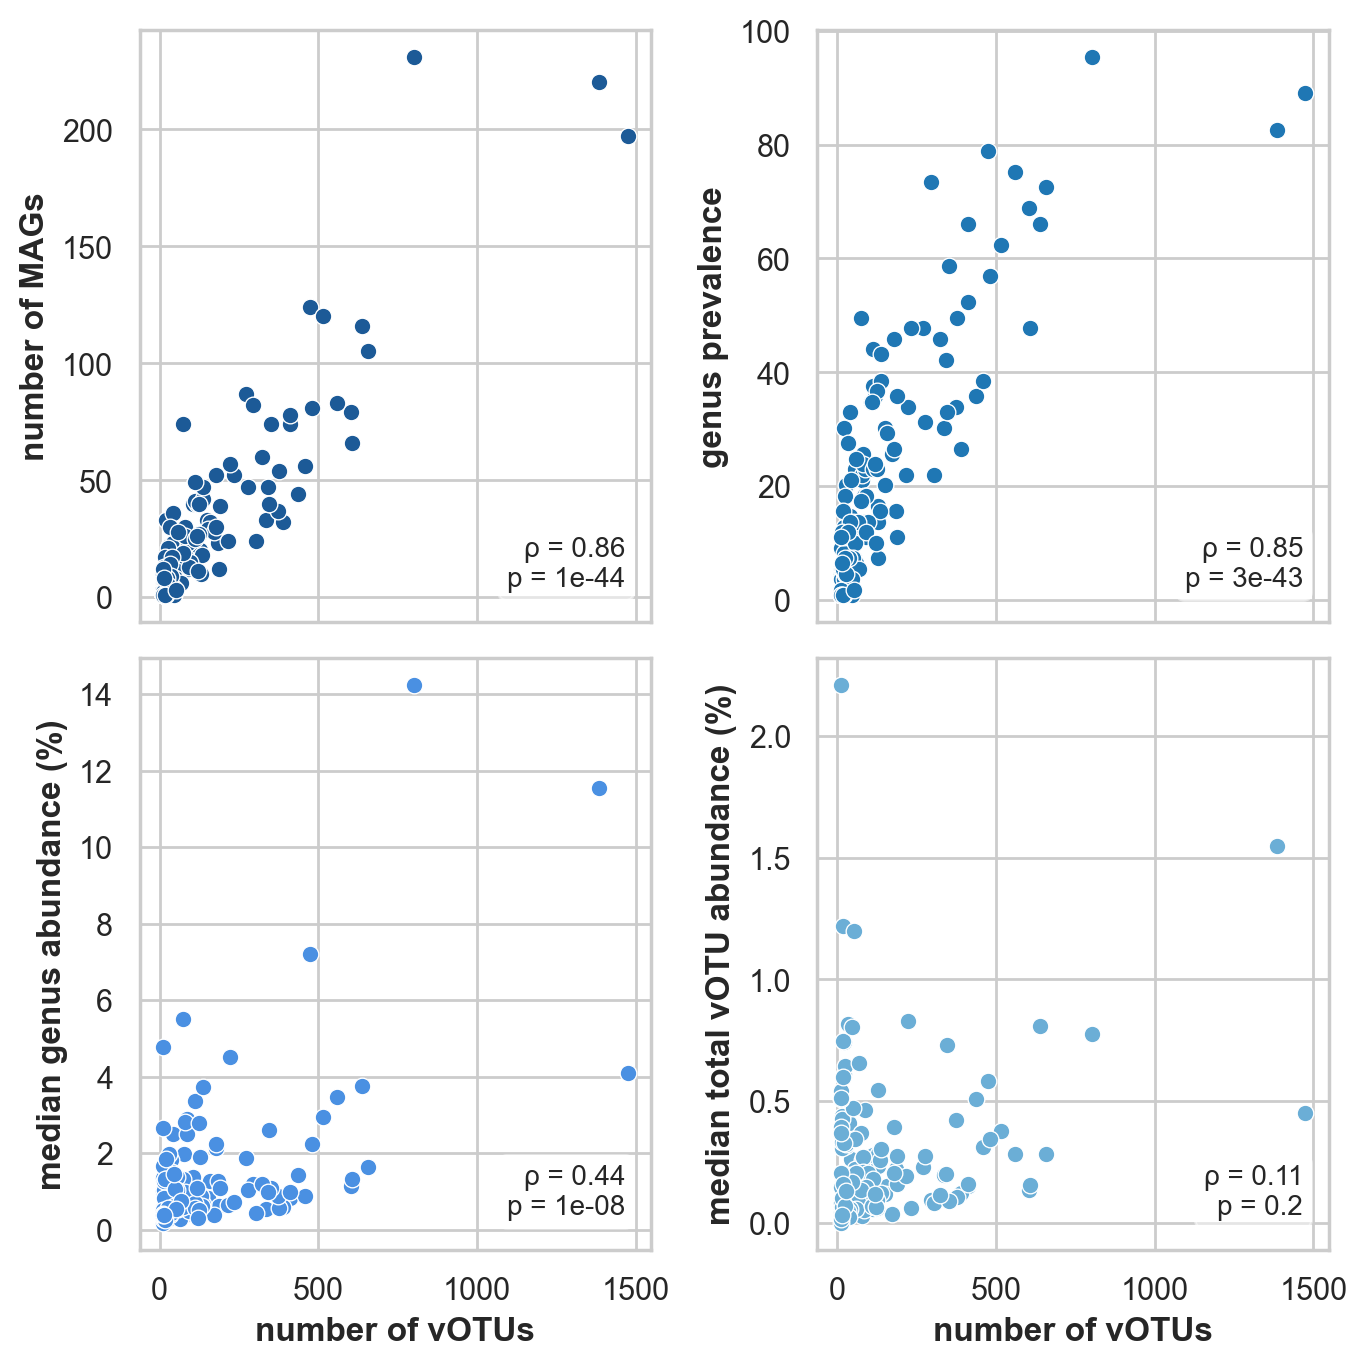

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

y_vars = ['num_mags', 'prevalence_g', 'median_perc_abun_g', 'median_perc_abun_v']

fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, dpi=200)
axes = axes.flatten()

for i, y_var in enumerate(y_vars):
    ax = axes[i]
    sns.scatterplot(data=df_h4, x='num_votus', y=y_var, ax=ax, color=colors[i])
    
    # Calculate Spearman correlation
    corr, pval = spearmanr(df_h4['num_votus'], df_h4[y_var])
    
    # Annotate on the top right
    ax.annotate(f'ρ = {corr:.2f}\np = {pval:.0g}', 
                xy=(0.95, 0.05), xycoords='axes fraction', 
                ha='right', va='bottom', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5))

axes[0].set_ylabel('number of MAGs', fontweight='bold')
axes[1].set_ylabel('genus prevalence', fontweight='bold')
axes[2].set_ylabel('median genus abundance (%)', fontweight='bold')
axes[3].set_ylabel('median total vOTU abundance (%)', fontweight='bold')

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[2].set_xlabel('number of vOTUs', fontweight='bold')
axes[3].set_xlabel('number of vOTUs', fontweight='bold')

plt.tight_layout()
plt.show()